### **Projeto 2 - Ciência de Dados**

*  **Nome**: Jansen Rodrigues de Avila
*  **Matrícula**: 2102410001

**Descrição Geral do Projeto**:

Com base nos dados coletados dos estudantes da Faculdade de Engenharia de Ciências da Educação, o propósito foi coletar dados para predizer a perfomance final com base em algoritmos de classificação de dados.
  

### **Carga de Dados**

**- Site de referência**: https://archive.ics.uci.edu/dataset/856/higher+education+students+performance+evaluation

**Higher Education Students Performance Evaluation***

The data was collected from the Faculty of Engineering and Faculty of Educational Sciences students in 2019. The purpose is to predict students' end-of-term performances using ML techniques.

- **Instâncias:** 145 (original)
- **Features:** 31

In [1]:
# Pacotes

import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split
import random

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, f1_score

#### **Carga de Dados e Preprocessamento**

In [2]:
link = "https://raw.githubusercontent.com/janavila/data-science/refs/heads/main/datasets/highStudent_valuation.csv"
dataframe = pd.read_csv(link, header=0)

# Renomeando as cólunas conforme descrição dos labels.

dataframe.columns = [
    'ID_ESTUDANTE',
    'Idade', 'Sexo', 'Tipo_Ensino_Medio', 'Bolsa', 'Trabalho_Extra',
    'Ativ_Artistica_Esportiva', 'Tem_Parceiro', 'Salario', 'Transporte', 'Moradia',
    'Escolaridade_Mae', 'Escolaridade_Pai', 'Qtd_Irmaos', 'Status_Parental',
    'Ocupacao_Mae', 'Ocupacao_Pai', 'Horas_Estudo', 'Leitura_Nao_Cientifica',
    'Leitura_Cientifica', 'Participacao_Seminario', 'Impacto_Projetos', 'Frequencia',
    'Prep_Prova_Parcial1', 'Prep_Prova_Parcial2', 'Anotacoes', 'Atencao_Aula',
    'Discussao', 'Aula_Invertida', 'IRA_Ultimo_Semestre', 'IRA_Esperado_Formatura',
    'ID_CURSO', 'NOTA'
]

# Pré processamento
# Remover as colunas ID_ESTUDANTE e ID_CURSO (não tem legenda para saber qual curso está performando melhor)

dataframe.drop(columns=['ID_ESTUDANTE', 'ID_CURSO'], inplace=True)

dataframe.head()

,Idade,Sexo,Tipo_Ensino_Medio,Bolsa,Trabalho_Extra,Ativ_Artistica_Esportiva,Tem_Parceiro,Salario,Transporte,Moradia,...,Frequencia,Prep_Prova_Parcial1,Prep_Prova_Parcial2,Anotacoes,Atencao_Aula,Discussao,Aula_Invertida,IRA_Ultimo_Semestre,IRA_Esperado_Formatura,NOTA
0,2,2,3,3,1,2,2,1,1,1,...,1,1,1,3,2,1,2,1,1,1
1,2,2,3,3,1,2,2,1,1,1,...,1,1,1,3,2,3,2,2,3,1
2,2,2,2,3,2,2,2,2,4,2,...,1,1,1,2,2,1,1,2,2,1
3,1,1,1,3,1,2,1,2,1,2,...,1,1,2,3,2,2,1,3,2,1
4,2,2,1,3,2,2,1,3,1,4,...,1,2,1,2,2,2,1,2,2,1


In [3]:
# Tendência de valores nas colunas.

for col in dataframe.columns:
    print(f"Column '{col}': {dataframe[col].unique()}")
    print(f"Number of unique values: {dataframe[col].nunique()}\n")

Column 'Idade': [2 1 3]
Number of unique values: 3

Column 'Sexo': [2 1]
Number of unique values: 2

Column 'Tipo_Ensino_Medio': [3 2 1]
Number of unique values: 3

Column 'Bolsa': [3 4 5 2 1]
Number of unique values: 5

Column 'Trabalho_Extra': [1 2]
Number of unique values: 2

Column 'Ativ_Artistica_Esportiva': [2 1]
Number of unique values: 2

Column 'Tem_Parceiro': [2 1]
Number of unique values: 2

Column 'Salario': [1 2 3 4 5]
Number of unique values: 5

Column 'Transporte': [1 4 2 3]
Number of unique values: 4

Column 'Moradia': [1 2 4 3]
Number of unique values: 4

Column 'Escolaridade_Mae': [1 2 3 4 5 6]
Number of unique values: 6

Column 'Escolaridade_Pai': [2 3 4 5 1 6]
Number of unique values: 6

Column 'Qtd_Irmaos': [3 2 5 1 4]
Number of unique values: 5

Column 'Status_Parental': [1 2 3]
Number of unique values: 3

Column 'Ocupacao_Mae': [2 4 3 5 1]
Number of unique values: 5

Column 'Ocupacao_Pai': [5 1 4 3 2]
Number of unique values: 5

Column 'Horas_Estudo': [3 2 1 5 4]

In [4]:
# Distruição das Notas no dataset.

print("Distribuição das notas (variável alvo):")
print(dataframe['NOTA'].value_counts().sort_index())

print("\nEm percentual:")
print((dataframe['NOTA'].value_counts(normalize=True).sort_index() * 100).round(1))
# normalize=True → retorna proporção em vez de contagem
# * 100 → converte para percentual
# Dataframe está desbalanceado, a nota 1 (DD) representa 24.1% dos dados

Distribuição das notas (variável alvo):
NOTA
0     8
1    35
2    24
3    21
4    10
5    17
6    13
7    17
Name: count, dtype: int64

Em percentual:
NOTA
0     5.5
1    24.1
2    16.6
3    14.5
4     6.9
5    11.7
6     9.0
7    11.7
Name: proportion, dtype: float64


### **Estatísticas Descritivas**
Estatísticas das labels (colunas) do dataset.

/tmp/ipykernel_1845/1729336432.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


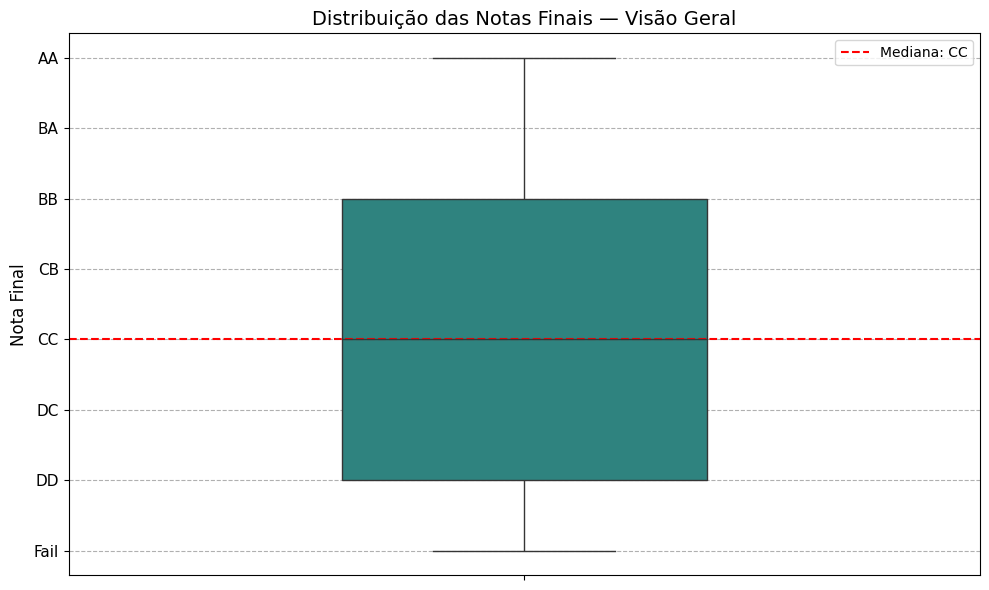

In [5]:
# Boxplots das Notas (target)

rotulos_nota = {0:'Fail', 1:'DD', 2:'DC', 3:'CC', 4:'CB', 5:'BB', 6:'BA', 7:'AA'}

fig, ax = plt.subplots(figsize=(10, 6))

sns.boxplot(
    y=dataframe['NOTA'],
    palette='viridis',
    ax=ax,
    width=0.4
)

# Substituindo os ticks numéricos pelos rótulos reais
ax.set_yticks(list(rotulos_nota.keys()))
ax.set_yticklabels(list(rotulos_nota.values()), fontsize=11)

ax.yaxis.grid(True, linestyle='--')
ax.set_axisbelow(True)

# Anotando mediana manualmente para destaque visual
mediana = dataframe['NOTA'].median()
ax.axhline(
    y=mediana,
    color='red', linestyle='--', linewidth=1.5,
    label=f'Mediana: {rotulos_nota[int(mediana)]}'
)

ax.set_title('Distribuição das Notas Finais — Visão Geral', fontsize=14)
ax.set_xlabel('')
ax.set_ylabel('Nota Final', fontsize=12)
ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig('grafico_boxplot_notas.png', dpi=300, bbox_inches='tight')
plt.show()

/tmp/ipykernel_1845/1102353732.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(
/tmp/ipykernel_1845/1102353732.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(
/tmp/ipykernel_1845/1102353732.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(
/tmp/ipykernel_1845/1102353732.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


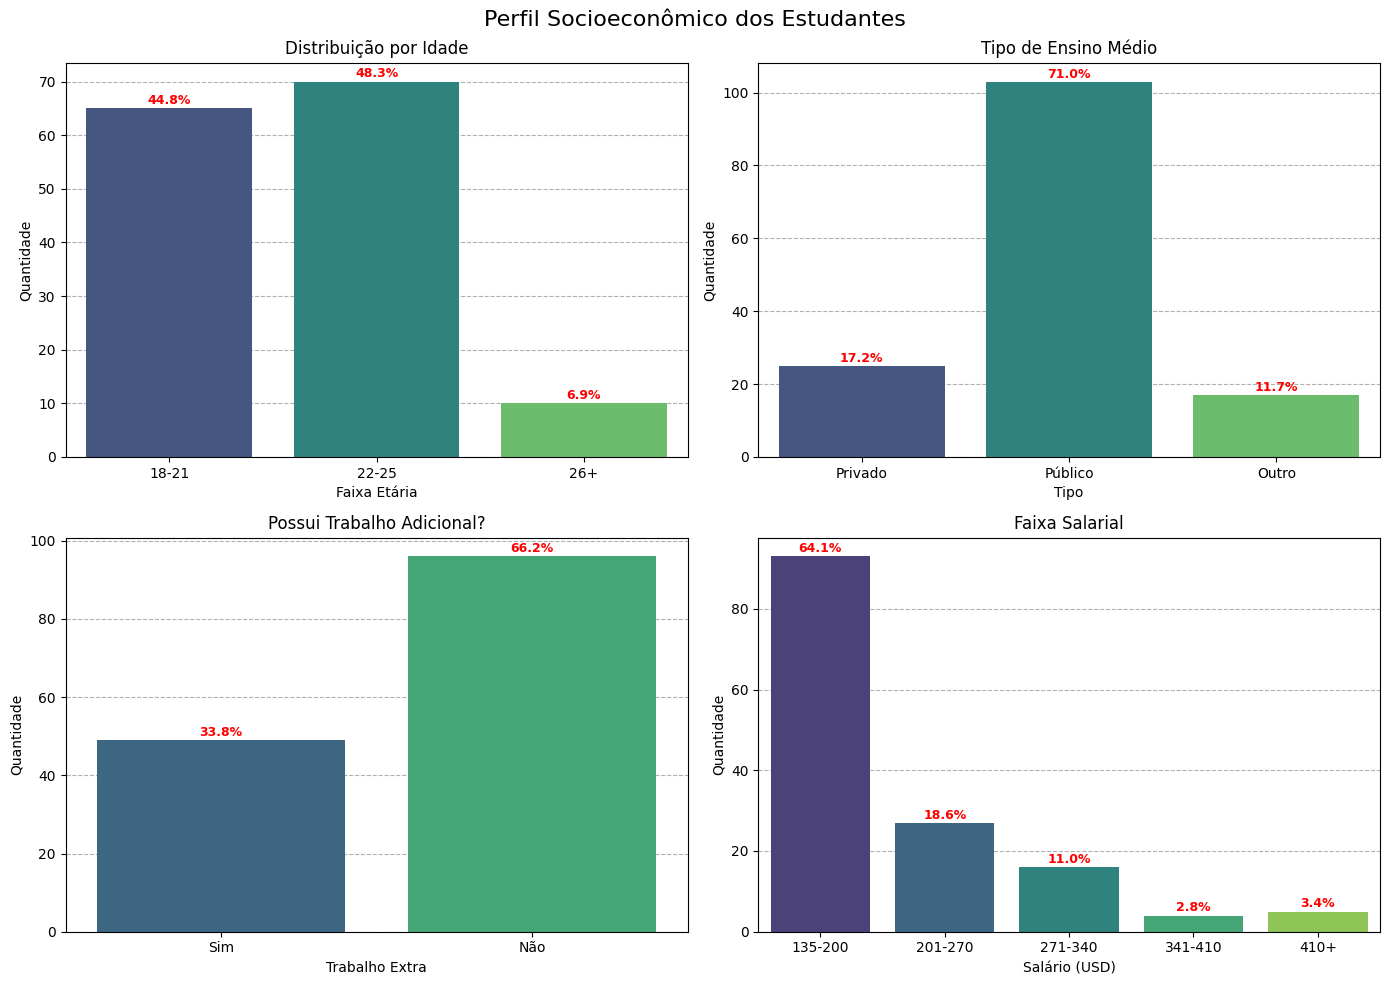

In [6]:
# Análise Perfil Socioeconômico (Idade, Ensino Médio, Trabalho, Salário)

rotulos_idade        = {1:'18-21', 2:'22-25', 3:'26+'}
rotulos_ensino_medio = {1:'Privado', 2:'Público', 3:'Outro'}
rotulos_trabalho     = {1:'Sim', 2:'Não'}
rotulos_salario      = {1:'135-200', 2:'201-270', 3:'271-340', 4:'341-410', 5:'410+'}

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

total = len(dataframe)

configs = [
    (axes[0,0], 'Idade',            rotulos_idade,        'Faixa Etária',    'Distribuição por Idade'),
    (axes[0,1], 'Tipo_Ensino_Medio', rotulos_ensino_medio, 'Tipo',           'Tipo de Ensino Médio'),
    (axes[1,0], 'Trabalho_Extra',   rotulos_trabalho,     'Trabalho Extra',  'Possui Trabalho Adicional?'),
    (axes[1,1], 'Salario',          rotulos_salario,      'Salário (USD)',   'Faixa Salarial'),
]

for ax, col, rotulos, xlabel, titulo in configs:
    sns.countplot(
        x=dataframe[col].map(rotulos),
        order=rotulos.values(),
        palette='viridis',
        ax=ax
    )
    ax.yaxis.grid(True, linestyle='--')
    ax.set_axisbelow(True)
    ax.set_title(titulo)
    ax.set_xlabel(xlabel)
    ax.set_ylabel('Quantidade')

    for container in ax.containers:
        for bar in container:
            height = bar.get_height()
            pct = f'{height/total*100:.1f}%'
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                height + 0.3,
                pct,
                ha='center', va='bottom',
                fontsize=9, color='red', fontweight='bold'
            )

plt.suptitle('Perfil Socioeconômico dos Estudantes', fontsize=16)
plt.tight_layout()
plt.savefig('grafico_socioeconomico.png', dpi=300, bbox_inches='tight')
plt.show()

/tmp/ipykernel_1845/2572229516.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(
/tmp/ipykernel_1845/2572229516.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(
/tmp/ipykernel_1845/2572229516.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(
/tmp/ipykernel_1845/2572229516.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


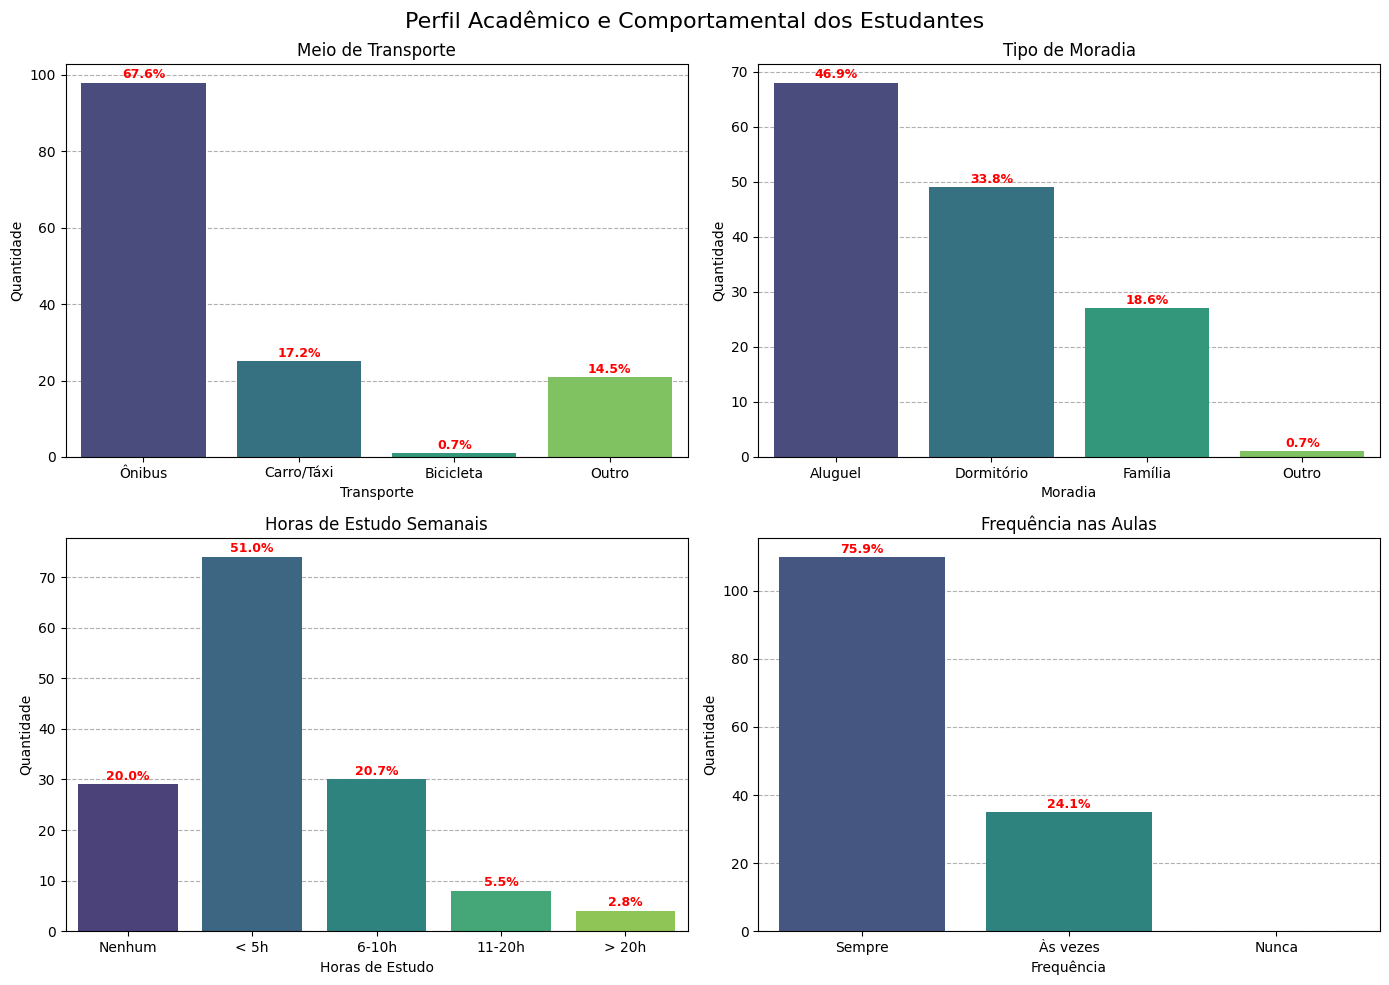

In [7]:
# Análise Perfil Acadêmico/Comportamental (Transporte, Moradia, Horas de Estudo, Frequência)

rotulos_transporte = {1:'Ônibus', 2:'Carro/Táxi', 3:'Bicicleta', 4:'Outro'}
rotulos_moradia    = {1:'Aluguel', 2:'Dormitório', 3:'Família', 4:'Outro'}
rotulos_horas      = {1:'Nenhum', 2:'< 5h', 3:'6-10h', 4:'11-20h', 5:'> 20h'}
rotulos_frequencia = {1:'Sempre', 2:'Às vezes', 3:'Nunca'}

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

total = len(dataframe)

configs = [
    (axes[0,0], 'Transporte',   rotulos_transporte, 'Transporte',      'Meio de Transporte'),
    (axes[0,1], 'Moradia',      rotulos_moradia,    'Moradia',         'Tipo de Moradia'),
    (axes[1,0], 'Horas_Estudo', rotulos_horas,      'Horas de Estudo', 'Horas de Estudo Semanais'),
    (axes[1,1], 'Frequencia',   rotulos_frequencia,  'Frequência',     'Frequência nas Aulas'),
]

for ax, col, rotulos, xlabel, titulo in configs:
    sns.countplot(
        x=dataframe[col].map(rotulos),
        order=rotulos.values(),
        palette='viridis',
        ax=ax
    )
    ax.yaxis.grid(True, linestyle='--')
    ax.set_axisbelow(True)
    ax.set_title(titulo)
    ax.set_xlabel(xlabel)
    ax.set_ylabel('Quantidade')

    for container in ax.containers:
        for bar in container:
            height = bar.get_height()
            pct = f'{height/total*100:.1f}%'
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                height + 0.3,
                pct,
                ha='center', va='bottom',
                fontsize=9, color='red', fontweight='bold'
            )

plt.suptitle('Perfil Acadêmico e Comportamental dos Estudantes', fontsize=16)
plt.tight_layout()
plt.savefig('grafico_academico_comportamental.png', dpi=300, bbox_inches='tight')
plt.show()

In [8]:
# Mapeamento das 8 classes originais para 4 categorias acadêmicas
# Baseado no sistema de notas europeu utilizado na universidade de Chipre

mapeamento_notas = {
    0: 'Reprovado',   # Fail  → < 40
    1: 'Reprovado',   # DD    → 40-49
    2: 'Reprovado',   # DC    → 50-59
    3: 'Suficiente',  # CC    → 60-69 (mínimo para passar)
    4: 'Suficiente',  # CB    → 70-74
    5: 'Bom',         # BB    → 75-84
    6: 'Bom',         # BA    → 85-89
    7: 'Excelente'    # AA    → 90-100
}

# .map() substitui cada valor numérico pelo rótulo correspondente
dataframe['NOTA_CATEGORIA'] = dataframe['NOTA'].map(mapeamento_notas)

# Verificando o resultado do mapeamento
print("Distribuição após mapeamento:")
print(dataframe['NOTA_CATEGORIA'].value_counts())

print("\nEm percentual:")
print((dataframe['NOTA_CATEGORIA'].value_counts(normalize=True) * 100).round(1))

Distribuição após mapeamento:
NOTA_CATEGORIA
Reprovado     67
Suficiente    31
Bom           30
Excelente     17
Name: count, dtype: int64

Em percentual:
NOTA_CATEGORIA
Reprovado     46.2
Suficiente    21.4
Bom           20.7
Excelente     11.7
Name: proportion, dtype: float64


### **Algoritmos de Classificação**
- Árvores de Decisão
- Random Forest
- KNN (se possível)

In [9]:
# Árvores de Decisão


X = dataframe.drop(columns=['NOTA', 'NOTA_CATEGORIA'])
y = dataframe['NOTA_CATEGORIA']

random.seed(42)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    train_size=0.8,
    stratify=y,
    random_state=42
)

print("Dimensões do training (inputs) dataset: ", X_train.shape)
print("Dimensões do testing (inputs) dataset: ", X_test.shape)
print("Dimensões do training (outputs) dataset: ", y_train.shape)
print("Dimensões do testing (outputs) dataset: ", y_test.shape)


clf_tree = DecisionTreeClassifier(
    criterion='gini',
    max_depth=5,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42
)

# Parâmetros principais:
#   - criterion='gini' → métrica usada para escolher a melhor divisão
#                        Gini mede a "impureza" do nó — quanto mais puro
#                        (uma só classe), melhor. Alternativa: 'entropy'
#   - max_depth=5      → profundidade máxima da árvore.
#                        Sem limite, a árvore cresce até classificar
#                        perfeitamente o treino (overfitting).
#                        Limitando, forçamos o modelo a generalizar.
#   - min_samples_split=5 → mínimo de amostras para dividir um nó.
#                           Evita divisões com pouquíssimas amostras,
#                           o que causaria overfitting.
#   - min_samples_leaf=2  → mínimo de amostras em cada folha (nó final).
#                           Folhas com 1 amostra = decoreba.
#   - random_state=42  → garante reprodutibilidade

clf_tree.fit(X_train, y_train)

print("Árvore de Decisão treinada com sucesso!")
print(f"Profundidade real da árvore: {clf_tree.get_depth()}")
print(f"Número de folhas: {clf_tree.get_n_leaves()}")

Dimensões do training (inputs) dataset:  (116, 30)
Dimensões do testing (inputs) dataset:  (29, 30)
Dimensões do training (outputs) dataset:  (116,)
Dimensões do testing (outputs) dataset:  (29,)
Árvore de Decisão treinada com sucesso!
Profundidade real da árvore: 5
Número de folhas: 19


DESEMPENHO NO CONJUNTO DE TREINO
Acurácia:    0.7328  (73.28%)
Taxa de erro:0.2672  (26.72%)

Matriz de Confusão — Treino:
[[19  1  4  0]
 [ 7  5  1  1]
 [ 4  0 49  0]
 [ 6  0  7 12]]


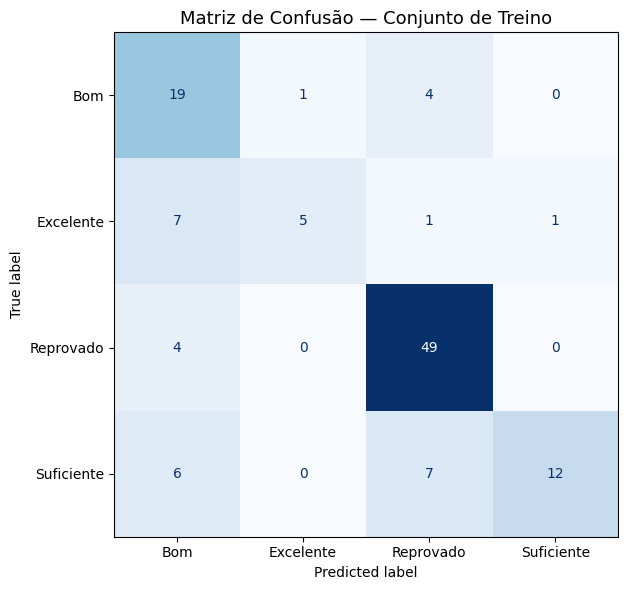


Classification Report — Treino:
              precision    recall  f1-score   support

         Bom       0.53      0.79      0.63        24
   Excelente       0.83      0.36      0.50        14
   Reprovado       0.80      0.92      0.86        53
  Suficiente       0.92      0.48      0.63        25

    accuracy                           0.73       116
   macro avg       0.77      0.64      0.66       116
weighted avg       0.78      0.73      0.72       116



In [10]:
# --- Predição no conjunto de TREINO ---
# .predict() aplica o modelo treinado para gerar previsões
# Avaliamos no treino para verificar se o modelo aprendeu bem
# (se a acurácia de treino for muito maior que a de teste → overfitting)
y_pred_train = clf_tree.predict(X_train)

acuracia_train = accuracy_score(y_train, y_pred_train)
taxa_erro_train = 1 - acuracia_train

print("=" * 50)
print("DESEMPENHO NO CONJUNTO DE TREINO")
print("=" * 50)
print(f"Acurácia:    {acuracia_train:.4f}  ({acuracia_train*100:.2f}%)")
print(f"Taxa de erro:{taxa_erro_train:.4f}  ({taxa_erro_train*100:.2f}%)")

classes = ['Bom', 'Excelente', 'Reprovado', 'Suficiente']

print("\nMatriz de Confusão — Treino:")
cm_train = confusion_matrix(y_train, y_pred_train, labels=classes)
print(cm_train)

fig, ax = plt.subplots(figsize=(8, 6))
disp_train = ConfusionMatrixDisplay(confusion_matrix=cm_train,
                                     display_labels=classes)
disp_train.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('Matriz de Confusão — Conjunto de Treino', fontsize=13)
plt.tight_layout()
plt.savefig('matriz_confusao_treino.png', dpi=300, bbox_inches='tight')
plt.show()

# Classification Report → métricas detalhadas por classe
# Precisão: dos que o modelo disse ser classe X, quantos realmente eram?
# Recall: dos que realmente são classe X, quantos o modelo acertou?
# F1-Score: média harmônica entre precisão e recall
print("\nClassification Report — Treino:")
print(classification_report(y_train, y_pred_train, target_names=classes))

DESEMPENHO NO CONJUNTO DE TESTE
Acurácia:    0.3793  (37.93%)
Taxa de erro:0.6207  (62.07%)

Matriz de Confusão — Teste:
[[2 2 1 1]
 [1 0 2 0]
 [2 2 8 2]
 [2 0 3 1]]


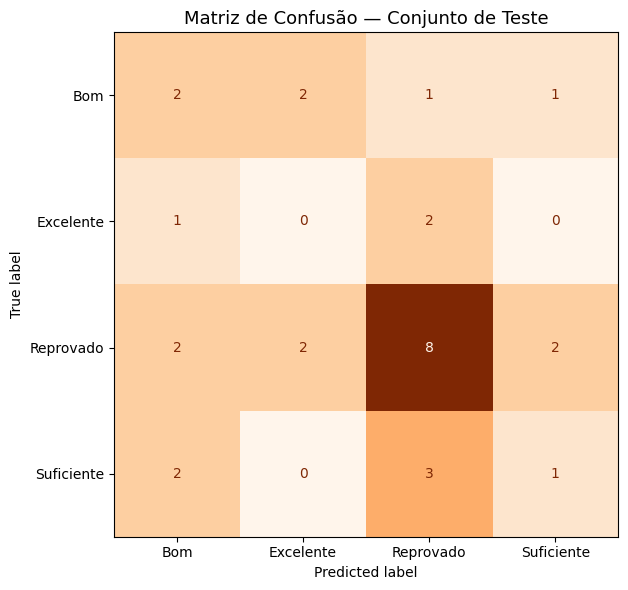


Classification Report — Teste:
              precision    recall  f1-score   support

         Bom       0.29      0.33      0.31         6
   Excelente       0.00      0.00      0.00         3
   Reprovado       0.57      0.57      0.57        14
  Suficiente       0.25      0.17      0.20         6

    accuracy                           0.38        29
   macro avg       0.28      0.27      0.27        29
weighted avg       0.39      0.38      0.38        29



In [11]:
# --- Predição no conjunto de TESTE ---
# Dados que o modelo NUNCA viu durante o treinamento
# Essa é a avaliação mais importante — reflete desempenho real
y_pred_test = clf_tree.predict(X_test)

acuracia_test = accuracy_score(y_test, y_pred_test)
taxa_erro_test = 1 - acuracia_test

print("=" * 50)
print("DESEMPENHO NO CONJUNTO DE TESTE")
print("=" * 50)
print(f"Acurácia:    {acuracia_test:.4f}  ({acuracia_test*100:.2f}%)")
print(f"Taxa de erro:{taxa_erro_test:.4f}  ({taxa_erro_test*100:.2f}%)")

# Matriz de Confusão do Teste
print("\nMatriz de Confusão — Teste:")
cm_test = confusion_matrix(y_test, y_pred_test, labels=classes)
print(cm_test)

fig, ax = plt.subplots(figsize=(8, 6))
disp_test = ConfusionMatrixDisplay(confusion_matrix=cm_test,
                                    display_labels=classes)
disp_test.plot(ax=ax, cmap='Oranges', colorbar=False)
ax.set_title('Matriz de Confusão — Conjunto de Teste', fontsize=13)
plt.tight_layout()
plt.savefig('matriz_confusao_teste.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nClassification Report — Teste:")
print(classification_report(y_test, y_pred_test, target_names=classes))

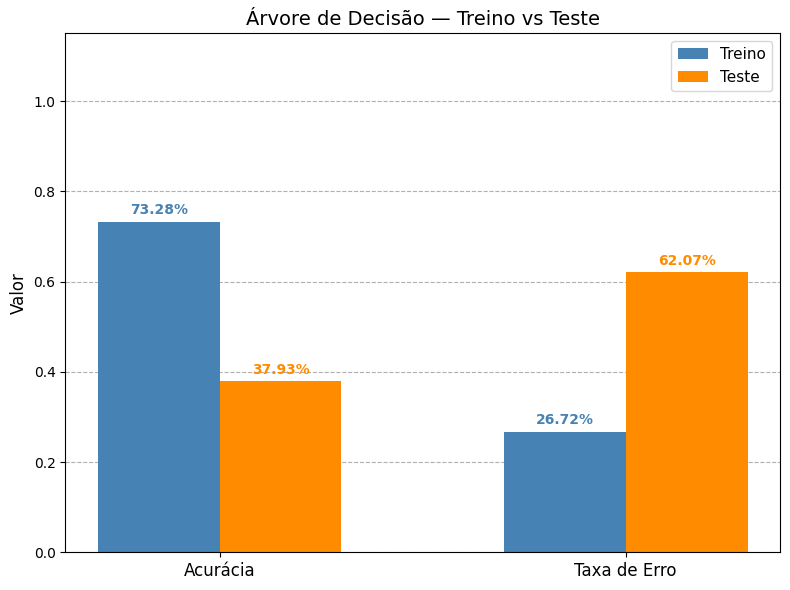

In [12]:
# Gráfico comparativo de acurácia e taxa de erro entre treino e teste
# Esse gráfico é fundamental para detectar overfitting:
# Se a acurácia de treino for muito superior à de teste,
# o modelo decorou os dados em vez de aprender padrões reais

metricas = ['Acurácia', 'Taxa de Erro']
valores_treino = [acuracia_train, taxa_erro_train]
valores_teste  = [acuracia_test,  taxa_erro_test]

x = np.arange(len(metricas))
largura = 0.3

fig, ax = plt.subplots(figsize=(8, 6))

barras_treino = ax.bar(x - largura/2, valores_treino, largura,
                        label='Treino', color='steelblue')
barras_teste  = ax.bar(x + largura/2, valores_teste,  largura,
                        label='Teste',  color='darkorange')

# Anotando os valores em cima de cada barra
for bar in barras_treino:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.2%}', ha='center', va='bottom',
            fontsize=10, fontweight='bold', color='steelblue')

for bar in barras_teste:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.2%}', ha='center', va='bottom',
            fontsize=10, fontweight='bold', color='darkorange')

ax.set_title('Árvore de Decisão — Treino vs Teste', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(metricas, fontsize=12)
ax.set_ylabel('Valor', fontsize=12)
ax.set_ylim(0, 1.15)
ax.yaxis.grid(True, linestyle='--')
ax.set_axisbelow(True)
ax.legend(fontsize=11)

plt.tight_layout()
plt.savefig('comparativo_treino_teste_arvore.png', dpi=300, bbox_inches='tight')
plt.show()

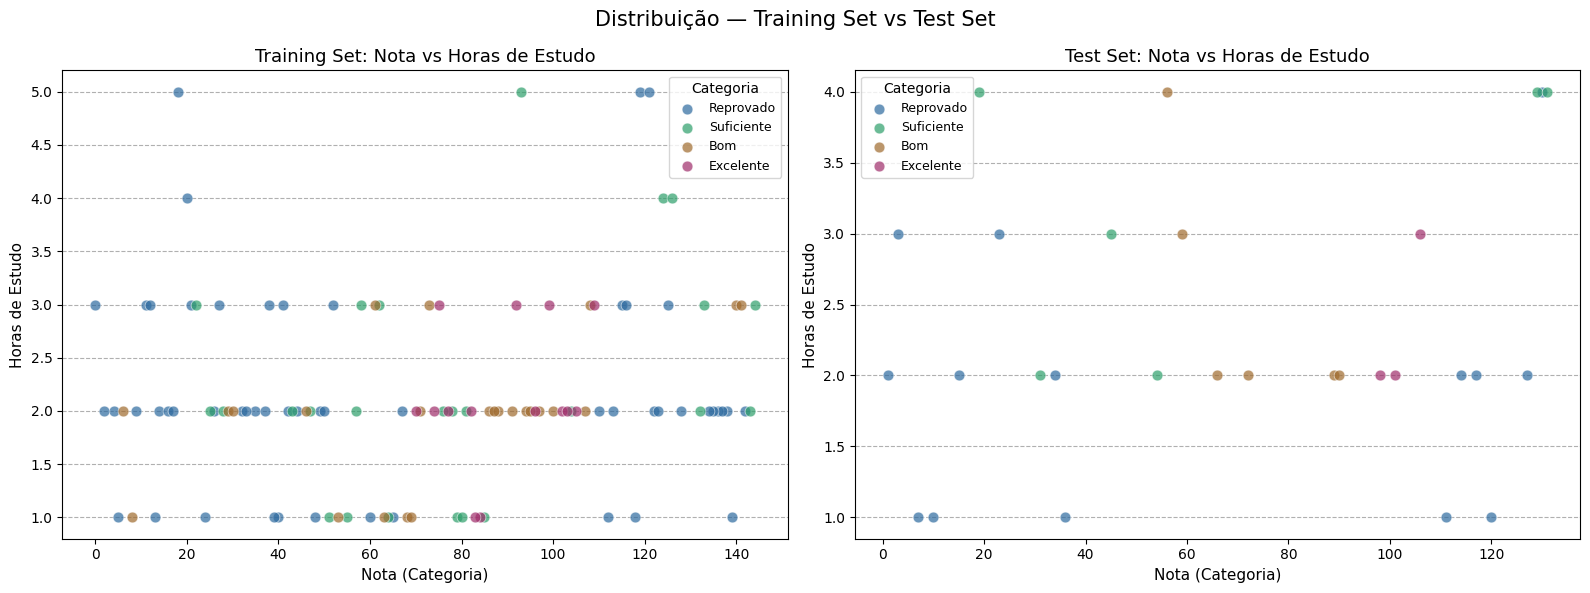

In [13]:
# Comparação do Training Set x Test Set para Notas x Horas de Estudo para ver se estão similares.

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Mapeamento para colorir os pontos por categoria
cores_categoria = {
    'Reprovado':  '#2d6a9f',
    'Suficiente': '#2d9f6a',
    'Bom':        '#9f6a2d',
    'Excelente':  '#9f2d6a'
}

# --- Training Set ---
for categoria, cor in cores_categoria.items():
    mask = y_train == categoria  # filtra apenas os pontos dessa categoria
    axes[0].scatter(
        X_train.loc[mask, 'NOTA_CATEGORIA'] if 'NOTA_CATEGORIA' in X_train else X_train[mask].index,
        X_train.loc[mask, 'Horas_Estudo'],
        # Usamos a nota original para o eixo X
        c=cor,
        label=categoria,
        alpha=0.7,   # transparência para ver sobreposição de pontos
        edgecolors='white',
        linewidths=0.5,
        s=60         # tamanho dos pontos
    )

axes[0].set_title('Training Set: Nota vs Horas de Estudo', fontsize=13)
axes[0].set_xlabel('Nota (Categoria)', fontsize=11)
axes[0].set_ylabel('Horas de Estudo', fontsize=11)
axes[0].yaxis.grid(True, linestyle='--')
axes[0].set_axisbelow(True)
axes[0].legend(title='Categoria', fontsize=9)

# --- Test Set ---
for categoria, cor in cores_categoria.items():
    mask = y_test == categoria
    axes[1].scatter(
        X_test.loc[mask, 'Horas_Estudo'].index,
        X_test.loc[mask, 'Horas_Estudo'],
        c=cor,
        label=categoria,
        alpha=0.7,
        edgecolors='white',
        linewidths=0.5,
        s=60
    )

axes[1].set_title('Test Set: Nota vs Horas de Estudo', fontsize=13)
axes[1].set_xlabel('Nota (Categoria)', fontsize=11)
axes[1].set_ylabel('Horas de Estudo', fontsize=11)
axes[1].yaxis.grid(True, linestyle='--')
axes[1].set_axisbelow(True)
axes[1].legend(title='Categoria', fontsize=9)

plt.suptitle('Distribuição — Training Set vs Test Set', fontsize=15)
plt.tight_layout()
plt.savefig('scatterplot_treino_teste.png', dpi=300, bbox_inches='tight')
plt.show()

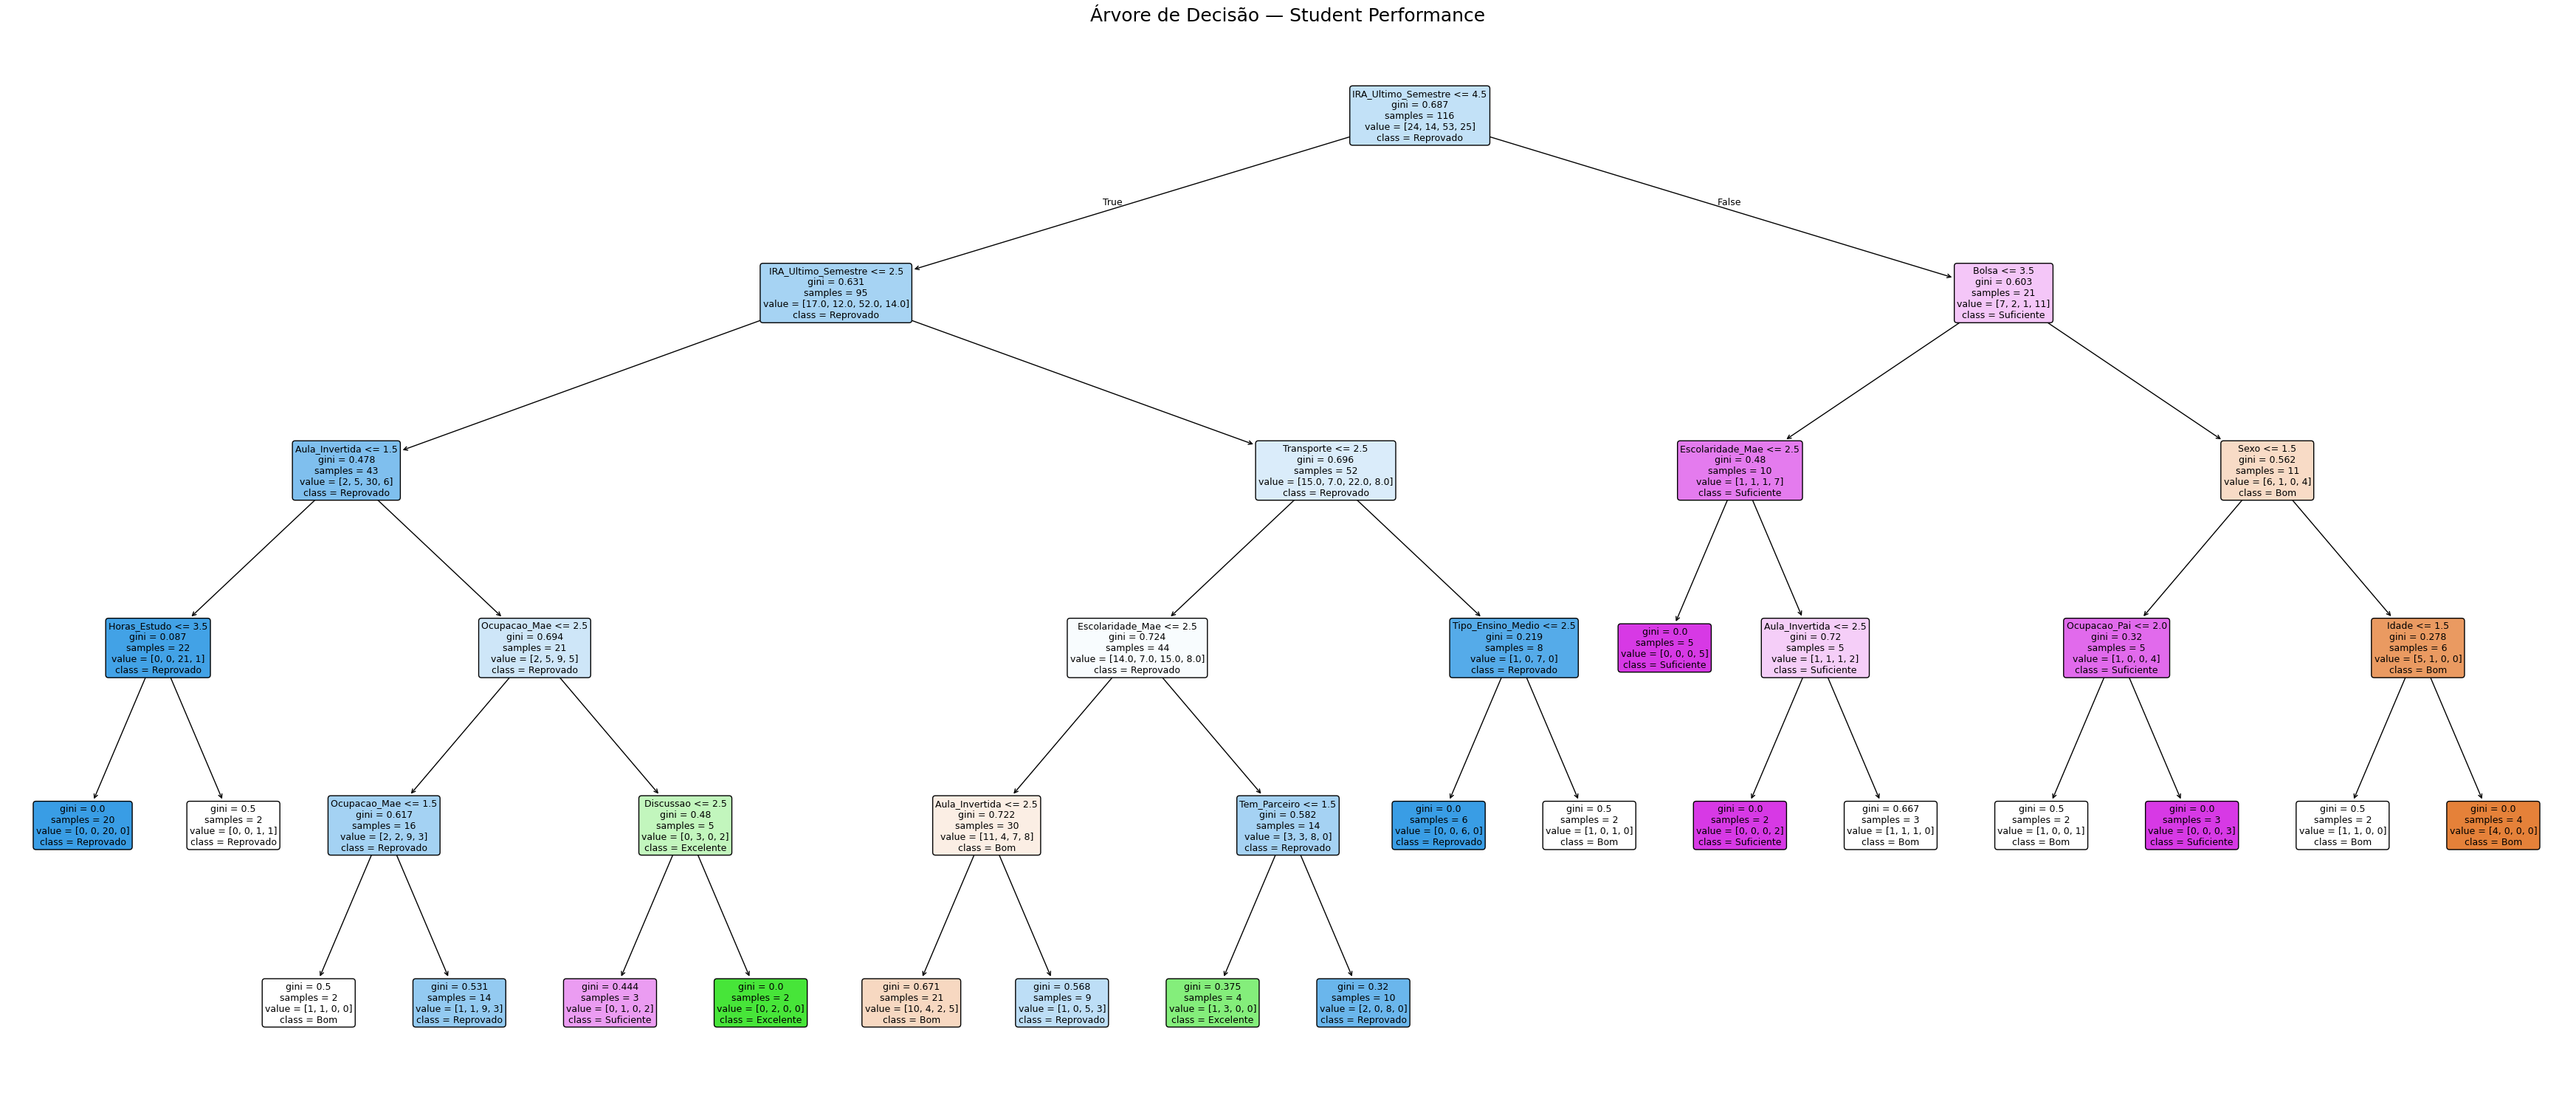

Árvore exportada como 'arvore_decisao.png'


In [14]:
# Exportando a visualização da árvore
# Com max_depth=5 e 30 features a árvore pode ficar grande,
# então usamos figsize generoso e exportamos em alta resolução
# para ser legível no PDF/slide

fig, ax = plt.subplots(figsize=(35, 15))

plot_tree(
    clf_tree,
    feature_names=X.columns.tolist(),  # nomes das features no eixo
    class_names=classes,               # nomes das classes nas folhas
    filled=True,       # colorir os nós pela classe dominante
    rounded=True,      # bordas arredondadas nos nós
    fontsize=9,        # tamanho da fonte dentro dos nós
    ax=ax
)

ax.set_title('Árvore de Decisão — Student Performance', fontsize=18)
plt.tight_layout()
plt.savefig('arvore_decisao.png', dpi=200, bbox_inches='tight')
plt.show()

print("Árvore exportada como 'arvore_decisao.png'")

In [15]:
# Colocar um gráfico para mostrar os pesos.

**Relatório - Árvore de Decisão.**

Conforme dito nas características do projeto, foi avaliado o desempenho dos estudantes com base em 4 classes: Reprovado (Fail, DD, DC), Suficiente (CC e CB), Bom (BB, BA) e Excelente (AA).

A distruição das classes ficaram da seguinte forma (dataset):
- Reprovado: 46,2%
- Suficiente: 21,4%
- Bom: 20,7%
- Excelente: 11,7%

A **mediana** se situa em CC (Suficiente).

- Método Holdout - 80% treino e 20% para teste.
- A arvore atingiu profundida 5 (max_depth) e 19 folhas.

- **Dados dos Sets**
  - **Training Set:** 73,28% Acurracy / 26,72% Error Rate
  - **Test Set:** 37,93% Accurary / 62,07% Error Rate

O modelo apresenta um overfitting pois não conseguiu acertar bem os dados de test, apenas decorou os de treino.

- **Matrizes de Confusão**
  - **Training Set:** a melhor taxa foi de reprovado (49/53)
  - **Test Set:** Também acertou mais os reprovados (8/14), porém, cai quase pela metade.

- **Resultados Métricas do Modelo**
  - ***Precisão:*** quantos classificados realmente eram.
    - Reprovado: 0,57%
    - Suficiente: 0,25%
    - Bom: 0,29%
    - **Excelente: 0,00%** - O modelo não conseguiu identificar NENHUM excelente. (eram apenas 17 amostras no dataset e 3 no set de teste)
  - ***Recall:*** quantos da classe realmente foram encontrados.
    - Reprovado: 0,57%
    - Suficiente: 0,17% (diminuição)
    - Bom: 0,33% (aumento)
    - **Excelente: 0,00**
  - F1-score: média harmônica entre Precisão e Recall, equilibra a capacidade do modelo de não cometer falsos positivos e não perder casos reais. Quanto mais próximo de 1 melhor.
    - Reprovado: 0,57%
    - Suficiente: 0,20%
    - Bom: 0,31%
    - **Excelente: 0,00%**

- Features com mais peso:
  - Índice de rendimento acadêmico anterior - IRA Anterior)
  - Bolsa
  - Aula Invertida
  ***- Escolaridade da Mãe.***

**- Pontos críticos:**
  - Overfitting severo (conforme demonstrado nos training/test set)
  - Dataset pequeno
  - Desbalanceamento para classe 'Excelente'
    - Possível Solução: Balanceamento de classes.


In [16]:
# Random Forest
# Treina VÁRIAS árvores simultaneamente, cada uma com:
#   1. Um subconjunto aleatório das AMOSTRAS (bootstrap sampling)
#   2. Um subconjunto aleatório das FEATURES em cada divisão
# A predição final é feita por VOTAÇÃO MAJORITÁRIA e pode melhorar o overfitting, porque se uma árvore decorar um conjunto, ainda fica dependente da votação majoritária.

clf_rf = RandomForestClassifier(
    n_estimators=100,
    criterion='gini',
    max_depth=5,
    min_samples_split=5,
    min_samples_leaf=2,
    max_features='sqrt',
    random_state=42
)

# Parâmetros principais:
#   - n_estimators=100 → número de árvores na floresta.
#                        Mais árvores = mais estável, mas mais lento.
#                        100 é um bom ponto de partida.
#   - criterion='gini' → mesmo critério de divisão da Árvore anterior.
#                        Mantemos igual para comparação justa.
#   - max_depth=5      → profundidade máxima de cada árvore individual.
#                        Mesmo valor da árvore anterior, mesma razão.
#   - min_samples_split=5 → mínimo de amostras para dividir um nó.
#   - min_samples_leaf=2  → mínimo de amostras em cada folha.
#   - max_features='sqrt' → número de features avaliadas em cada divisão.
#                           'sqrt' = raiz quadrada do total de features.
#                           Com 30 features → avalia ~5 por divisão.
#                           Isso força diversidade entre as árvores!
#   - random_state=42  → reprodutibilidade

clf_rf.fit(X_train, y_train)

print("Random Forest treinado com sucesso!")
print(f"Número de árvores: {clf_rf.n_estimators}")
print(f"Features por divisão (~sqrt de 30): {clf_rf.max_features}")

# As dimensões de treinamento são as mesmas da árvore de decisão.

Random Forest treinado com sucesso!
Número de árvores: 100
Features por divisão (~sqrt de 30): sqrt


RANDOM FOREST — DESEMPENHO NO TREINO
Acurácia:     0.8534  (85.34%)
Taxa de Erro: 0.1466  (14.66%)


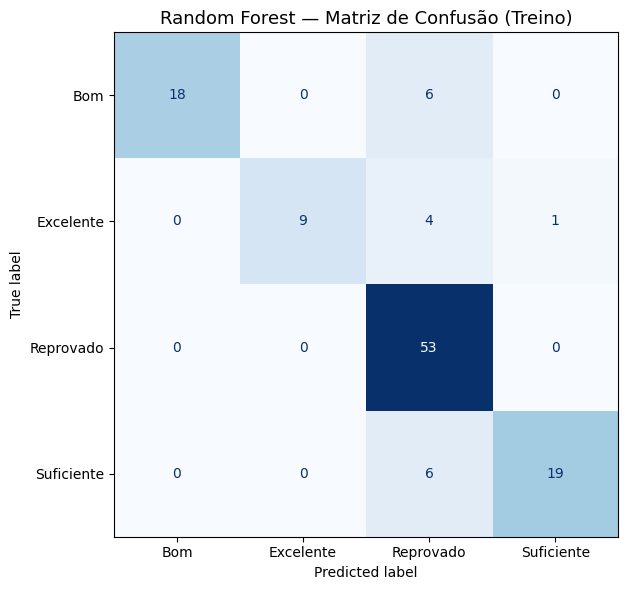


Classification Report — Treino:
              precision    recall  f1-score   support

         Bom       1.00      0.75      0.86        24
   Excelente       1.00      0.64      0.78        14
   Reprovado       0.77      1.00      0.87        53
  Suficiente       0.95      0.76      0.84        25

    accuracy                           0.85       116
   macro avg       0.93      0.79      0.84       116
weighted avg       0.88      0.85      0.85       116



In [17]:
# Predição no conjunto de TREINO
y_pred_rf_train = clf_rf.predict(X_train)

acuracia_rf_train = accuracy_score(y_train, y_pred_rf_train)
taxa_erro_rf_train = 1 - acuracia_rf_train

print("=" * 50)
print("RANDOM FOREST — DESEMPENHO NO TREINO")
print("=" * 50)
print(f"Acurácia:     {acuracia_rf_train:.4f}  ({acuracia_rf_train*100:.2f}%)")
print(f"Taxa de Erro: {taxa_erro_rf_train:.4f}  ({taxa_erro_rf_train*100:.2f}%)")

# Matriz de Confusão — Treino
fig, ax = plt.subplots(figsize=(8, 6))
cm_rf_train = confusion_matrix(y_train, y_pred_rf_train, labels=classes)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_rf_train, display_labels=classes)
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('Random Forest — Matriz de Confusão (Treino)', fontsize=13)
plt.tight_layout()
plt.savefig('rf_matriz_confusao_treino.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nClassification Report — Treino:")
print(classification_report(y_train, y_pred_rf_train, target_names=classes))

RANDOM FOREST — DESEMPENHO NO TESTE
Acurácia:     0.5517  (55.17%)
Taxa de Erro: 0.4483  (44.83%)


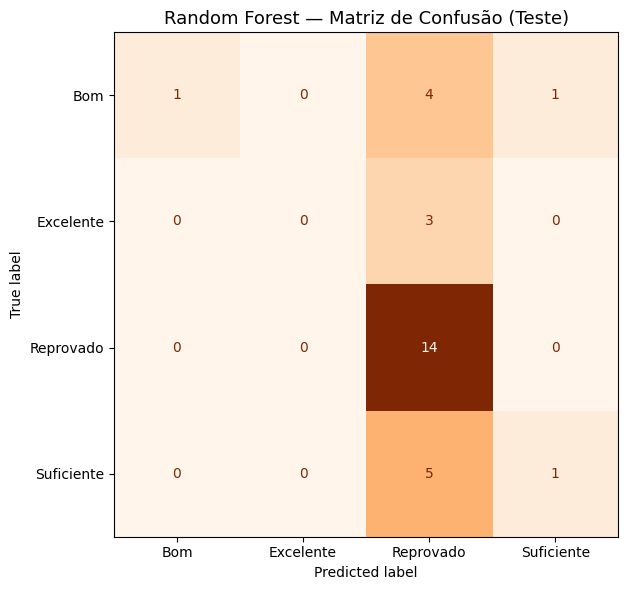


Classification Report — Teste:
              precision    recall  f1-score   support

         Bom       1.00      0.17      0.29         6
   Excelente       0.00      0.00      0.00         3
   Reprovado       0.54      1.00      0.70        14
  Suficiente       0.50      0.17      0.25         6

    accuracy                           0.55        29
   macro avg       0.51      0.33      0.31        29
weighted avg       0.57      0.55      0.45        29



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [18]:
# Predição no conjunto de TESTE
y_pred_rf_test = clf_rf.predict(X_test)

acuracia_rf_test = accuracy_score(y_test, y_pred_rf_test)
taxa_erro_rf_test = 1 - acuracia_rf_test

print("=" * 50)
print("RANDOM FOREST — DESEMPENHO NO TESTE")
print("=" * 50)
print(f"Acurácia:     {acuracia_rf_test:.4f}  ({acuracia_rf_test*100:.2f}%)")
print(f"Taxa de Erro: {taxa_erro_rf_test:.4f}  ({taxa_erro_rf_test*100:.2f}%)")

# Matriz de Confusão — Teste
fig, ax = plt.subplots(figsize=(8, 6))
cm_rf_test = confusion_matrix(y_test, y_pred_rf_test, labels=classes)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_rf_test, display_labels=classes)
disp.plot(ax=ax, cmap='Oranges', colorbar=False)
ax.set_title('Random Forest — Matriz de Confusão (Teste)', fontsize=13)
plt.tight_layout()
plt.savefig('rf_matriz_confusao_teste.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nClassification Report — Teste:")
print(classification_report(y_test, y_pred_rf_test, target_names=classes))

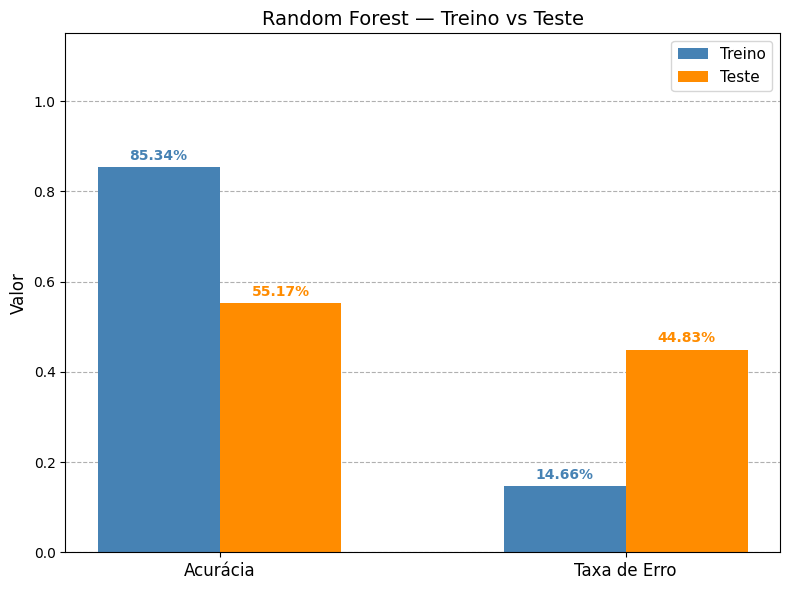

In [19]:
# Comparativo Training Set x Test Set

metricas = ['Acurácia', 'Taxa de Erro']
valores_treino = [acuracia_rf_train, taxa_erro_rf_train]
valores_teste  = [acuracia_rf_test,  taxa_erro_rf_test]

x = np.arange(len(metricas))
largura = 0.3

fig, ax = plt.subplots(figsize=(8, 6))

barras_treino = ax.bar(x - largura/2, valores_treino, largura,
                       label='Treino', color='steelblue')
barras_teste  = ax.bar(x + largura/2, valores_teste,  largura,
                       label='Teste',  color='darkorange')

for bar in barras_treino:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.2%}', ha='center', va='bottom',
            fontsize=10, fontweight='bold', color='steelblue')

for bar in barras_teste:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.2%}', ha='center', va='bottom',
            fontsize=10, fontweight='bold', color='darkorange')

ax.set_title('Random Forest — Treino vs Teste', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(metricas, fontsize=12)
ax.set_ylabel('Valor', fontsize=12)
ax.set_ylim(0, 1.15)
ax.yaxis.grid(True, linestyle='--')
ax.set_axisbelow(True)
ax.legend(fontsize=11)

plt.tight_layout()
plt.savefig('rf_comparativo_treino_teste.png', dpi=300, bbox_inches='tight')
plt.show()

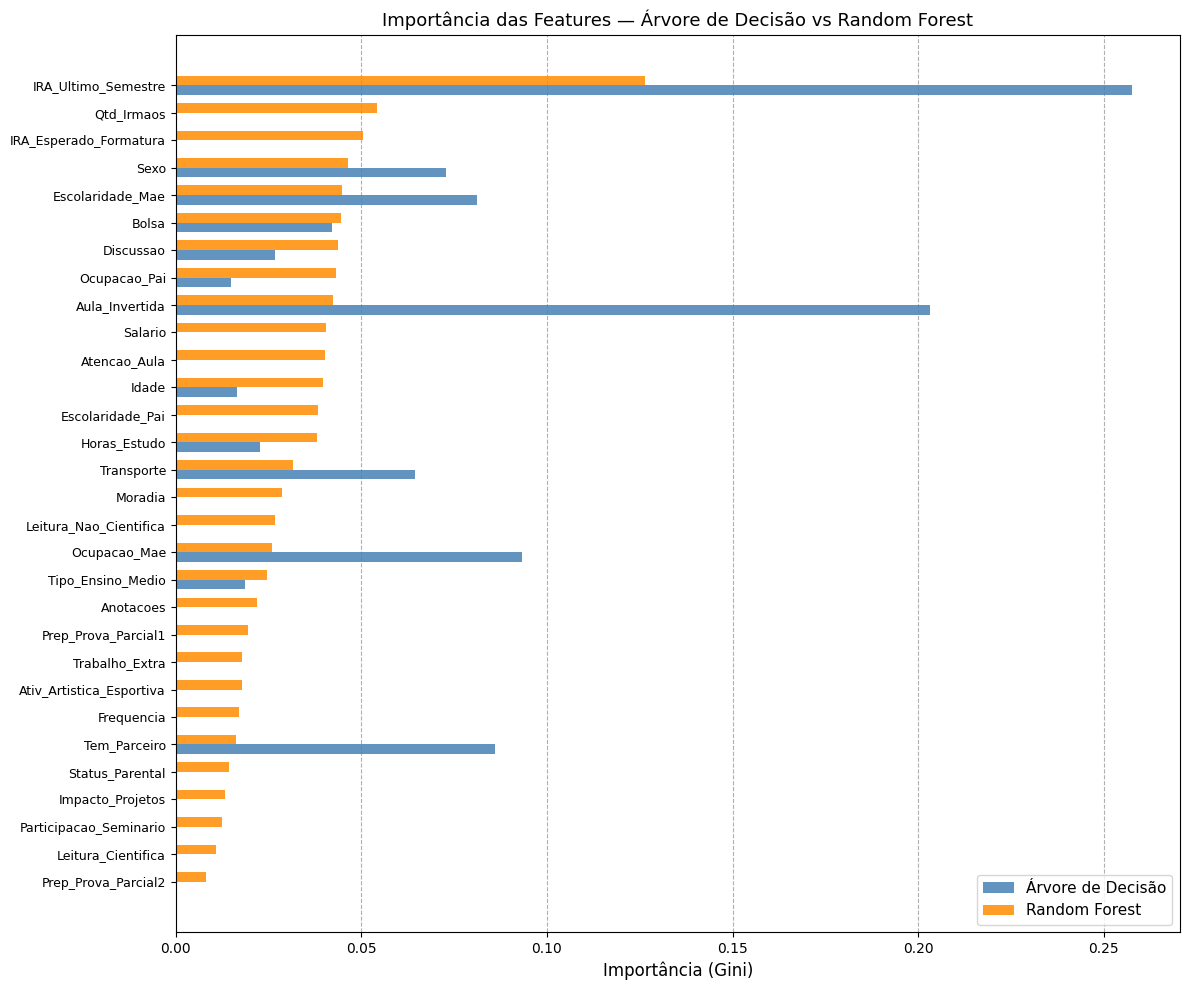

In [20]:
# Importância das features — Árvore de Decisão vs Random Forest
# O quanto cada feature contribuiu para as decisões do modelo, calculado como a média da redução de impureza (Gini) que cada feature causou em todas as árvores da floresta.

importancias_tree = pd.Series(clf_tree.feature_importances_, index=X.columns)
importancias_rf   = pd.Series(clf_rf.feature_importances_,   index=X.columns)

# Ordenamos pela importância do Random Forest para facilitar comparação
ordem = importancias_rf.sort_values(ascending=True).index

fig, ax = plt.subplots(figsize=(12, 10))

y_pos = np.arange(len(ordem))
largura = 0.35

# Barras horizontais lado a lado
ax.barh(y_pos - largura/2, importancias_tree[ordem], largura,
        label='Árvore de Decisão', color='steelblue', alpha=0.85)
ax.barh(y_pos + largura/2, importancias_rf[ordem],   largura,
        label='Random Forest',     color='darkorange', alpha=0.85)

ax.set_yticks(y_pos)
ax.set_yticklabels(ordem, fontsize=9)
ax.set_xlabel('Importância (Gini)', fontsize=12)
ax.set_title('Importância das Features — Árvore de Decisão vs Random Forest',
             fontsize=13)
ax.xaxis.grid(True, linestyle='--')
ax.set_axisbelow(True)
ax.legend(fontsize=11)

plt.tight_layout()
plt.savefig('comparativo_importancia_features.png', dpi=300, bbox_inches='tight')
plt.show()

**Relatório - Random Forest.**

Treina diversas árvores de decisão simultaneamente — neste caso, 100 árvores. Cada árvore é treinada com um subconjunto aleatório das amostras e das features, e a classificação final é decidida por votação majoritária entre todas elas.

- n_estimators: 100 (número de árvores)
- max_features: sqrt - cerca de 5 a cada 30

Foram mantidos os parametros da árvore de decisão para manter o padrão e ser possível a comparação.

- **Dados dos Sets**
  - **Training Set:** 85,34% Acurracy / 14,66% Error Rate
  - **Test Set:** 55,17% Accurary / 44,83% Error Rate

O overfitting foi reduzido em comparação a árvore de decisão.

- **Matrizes de Confusão**
  - **Training Set:** Acertou todos os reprovados.
  - **Test Set:** Também acertou todos os reprovados (8/14), mas deixou a desejar no excelente e no bom.

- **Resultados Métricas do Modelo**
  - ***Precisão:*** quantos classificados realmente eram.
    - Reprovado: 0,54%
    - Suficiente: 0,50%
    - Bom: 1,00%
    - **Excelente: 0,00%** - O modelo não conseguiu identificar NENHUM excelente. (eram apenas 17 amostras no dataset e 3 no set de teste)
  - ***Recall:*** quantos da classe realmente foram encontrados.
    - Reprovado: 1,00% (o modelo aprendeu a chutar muito em reprovado)
    - Suficiente: 0,17% (mantém)
    - Bom: 0,17% (diminuição em comparação ao random forest)
    - **Excelente: 0,00**
  - F1-score: média harmônica entre Precisão e Recall, equilibra a capacidade do modelo de não cometer falsos positivos e não perder casos reais. Quanto mais próximo de 1 melhor.
    - Reprovado: 0,70% (aumentou)
    - Suficiente: 0,25% (aumentou)
    - Bom: 0,29% (diminuiu)
    - **Excelente: 0,00%**

A métrica "Bom" apresentou uma falsa precisão devido ao recall ser 0,17. Ou seja, ele acertou o Bom quando perguntado, mas errou os que realmente eram. O modelo é mais cauteloso com classes minoritárias, mas quando escolhe tende a acertar.

- Features com mais peso:
No random forest, é analisado a importância agrega, calculando a média da redução de impureza (gini) ao longo das 100 árvores.
  - Índice de rendimento acadêmico anterior - IRA Anterior)
  - Qtd_Irmaos
  - IRA Esperado durante a graduação
  - **Sexo**
  - **Escolaridade da Mãe.**

**- Pontos críticos:**
- Foi notado uma melhora, porém o overfitting ainda está presente, principalmente para as classes minoritárias que o modelo não consegue distinguir bem ainda, com destaque para o "Excelente".
- O tamanho do dataset ainda configura uma grande desvantagem.

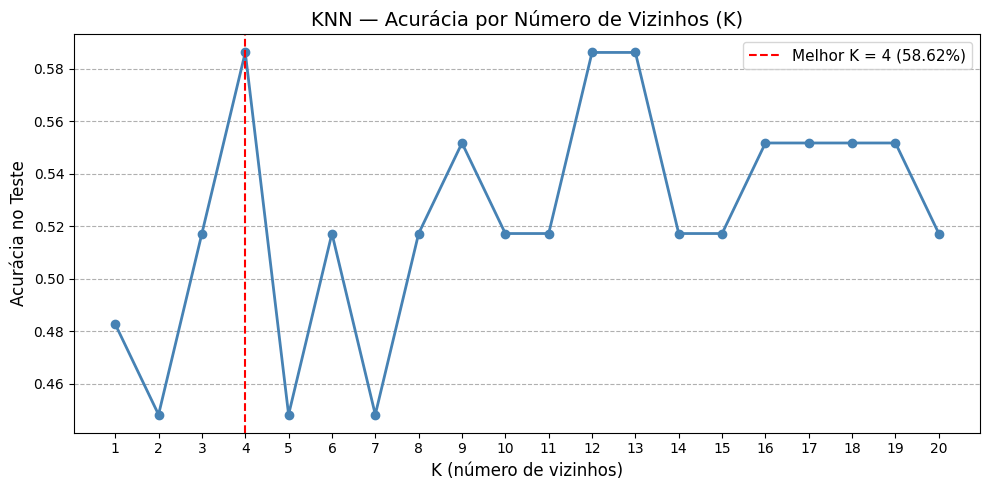

Melhor K encontrado: 4
Acurácia com melhor K: 58.62%
KNN treinado com sucesso! K = 4


In [21]:
# KNN
# Calcula a distância entre pontos no espaço de features. em normalização, uma feature que vai de 1 a 6 teria mais peso no cálculo de distância do que uma que vai de 1 a 2, simplesmente
# pela diferença de escala — e não pelo seu valor preditivo real.

scaler = StandardScaler()

X_train_knn = scaler.fit_transform(X_train)   # aprende + transforma
X_test_knn  = scaler.transform(X_test)        # apenas transforma

# Mesma dimensões.

# Antes de treinar o KNN, deve ser encontrado o melhor K.
# K é o número de vizinhos que o algoritmo consulta para votar.
# K muito pequeno (ex: K=1) → overfitting (o modelo "decora")
# K muito grande (ex: K=50) → underfitting (média geral sem distinção)
# K de 1 a 20 e verificamos qual gera maior acurácia no teste

acuracias_k = []

for k in range(1, 21):
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_knn, y_train)
    acuracia = accuracy_score(y_test, knn.predict(X_test_knn))
    acuracias_k.append(acuracia)

# Plotando a curva de acurácia por K
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(range(1, 21), acuracias_k, marker='o', color='steelblue', linewidth=2)

# Destacando o melhor K
melhor_k = acuracias_k.index(max(acuracias_k)) + 1
ax.axvline(x=melhor_k, color='red', linestyle='--',
           label=f'Melhor K = {melhor_k} ({max(acuracias_k)*100:.2f}%)')

ax.set_title('KNN — Acurácia por Número de Vizinhos (K)', fontsize=14)
ax.set_xlabel('K (número de vizinhos)', fontsize=12)
ax.set_ylabel('Acurácia no Teste', fontsize=12)
ax.yaxis.grid(True, linestyle='--')
ax.set_axisbelow(True)
ax.legend(fontsize=11)
ax.set_xticks(range(1, 21))

plt.tight_layout()
plt.savefig('knn_curva_k.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"Melhor K encontrado: {melhor_k}")
print(f"Acurácia com melhor K: {max(acuracias_k)*100:.2f}%")

clf_knn = KNeighborsClassifier(
    n_neighbors=melhor_k,
    metric='euclidean',
    weights='uniform'
)

clf_knn.fit(X_train_knn, y_train)
print(f"KNN treinado com sucesso! K = {melhor_k}")

KNN — DESEMPENHO NO TREINO
Acurácia:     0.6552  (65.52%)
Taxa de Erro: 0.3448  (34.48%)


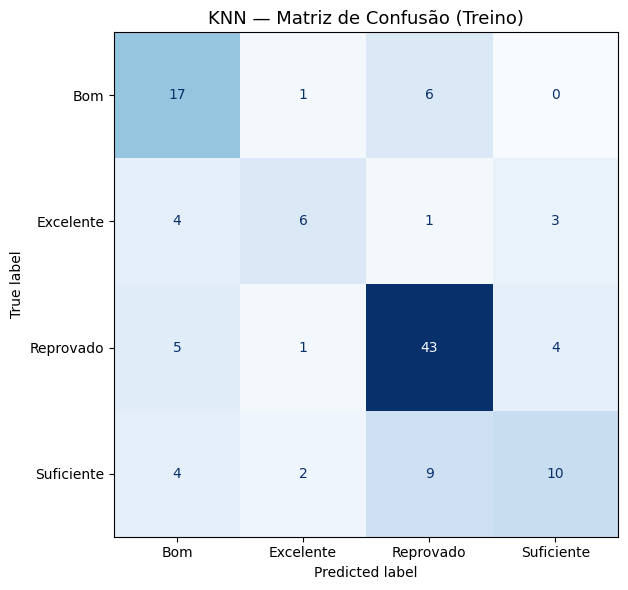


Classification Report — Treino:
              precision    recall  f1-score   support

         Bom       0.57      0.71      0.63        24
   Excelente       0.60      0.43      0.50        14
   Reprovado       0.73      0.81      0.77        53
  Suficiente       0.59      0.40      0.48        25

    accuracy                           0.66       116
   macro avg       0.62      0.59      0.59       116
weighted avg       0.65      0.66      0.64       116



In [22]:
y_pred_knn_train = clf_knn.predict(X_train_knn)

acuracia_knn_train = accuracy_score(y_train, y_pred_knn_train)
taxa_erro_knn_train = 1 - acuracia_knn_train

print("=" * 50)
print("KNN — DESEMPENHO NO TREINO")
print("=" * 50)
print(f"Acurácia:     {acuracia_knn_train:.4f}  ({acuracia_knn_train*100:.2f}%)")
print(f"Taxa de Erro: {taxa_erro_knn_train:.4f}  ({taxa_erro_knn_train*100:.2f}%)")

fig, ax = plt.subplots(figsize=(8, 6))
cm_knn_train = confusion_matrix(y_train, y_pred_knn_train, labels=classes)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_knn_train, display_labels=classes)
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('KNN — Matriz de Confusão (Treino)', fontsize=13)
plt.tight_layout()
plt.savefig('knn_matriz_confusao_treino.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nClassification Report — Treino:")
print(classification_report(y_train, y_pred_knn_train, target_names=classes))

KNN — DESEMPENHO NO TESTE
Acurácia:     0.5862  (58.62%)
Taxa de Erro: 0.4138  (41.38%)


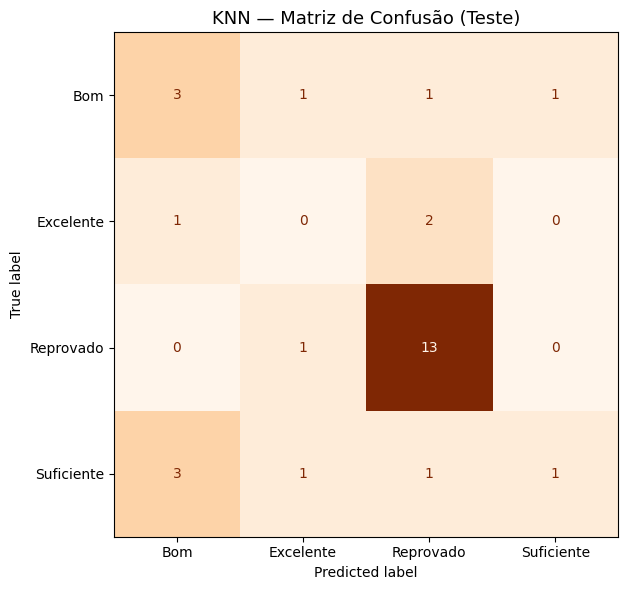


Classification Report — Teste:
              precision    recall  f1-score   support

         Bom       0.43      0.50      0.46         6
   Excelente       0.00      0.00      0.00         3
   Reprovado       0.76      0.93      0.84        14
  Suficiente       0.50      0.17      0.25         6

    accuracy                           0.59        29
   macro avg       0.42      0.40      0.39        29
weighted avg       0.56      0.59      0.55        29



In [23]:
y_pred_knn_test = clf_knn.predict(X_test_knn)

acuracia_knn_test = accuracy_score(y_test, y_pred_knn_test)
taxa_erro_knn_test = 1 - acuracia_knn_test

print("=" * 50)
print("KNN — DESEMPENHO NO TESTE")
print("=" * 50)
print(f"Acurácia:     {acuracia_knn_test:.4f}  ({acuracia_knn_test*100:.2f}%)")
print(f"Taxa de Erro: {taxa_erro_knn_test:.4f}  ({taxa_erro_knn_test*100:.2f}%)")

fig, ax = plt.subplots(figsize=(8, 6))
cm_knn_test = confusion_matrix(y_test, y_pred_knn_test, labels=classes)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_knn_test, display_labels=classes)
disp.plot(ax=ax, cmap='Oranges', colorbar=False)
ax.set_title('KNN — Matriz de Confusão (Teste)', fontsize=13)
plt.tight_layout()
plt.savefig('knn_matriz_confusao_teste.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nClassification Report — Teste:")
print(classification_report(y_test, y_pred_knn_test, target_names=classes))

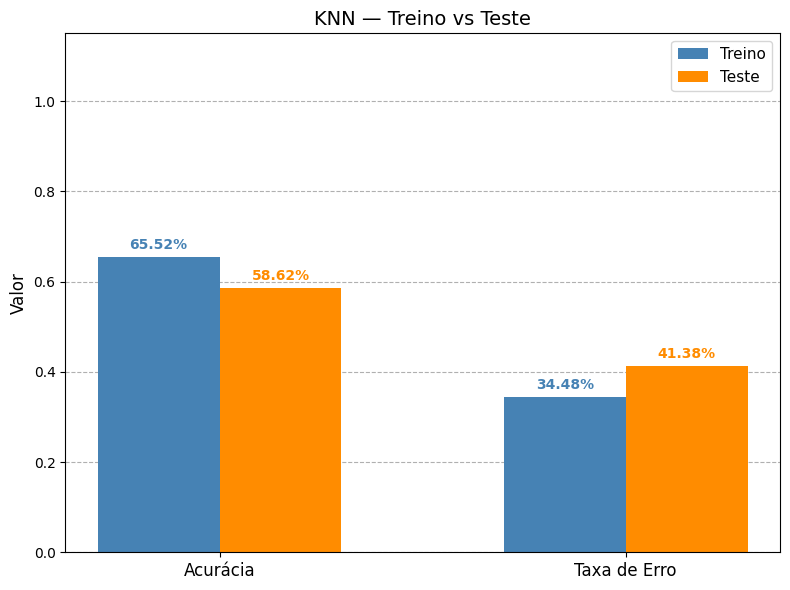

In [24]:
metricas = ['Acurácia', 'Taxa de Erro']
valores_treino = [acuracia_knn_train, taxa_erro_knn_train]
valores_teste  = [acuracia_knn_test,  taxa_erro_knn_test]

x = np.arange(len(metricas))
largura = 0.3

fig, ax = plt.subplots(figsize=(8, 6))

barras_treino = ax.bar(x - largura/2, valores_treino, largura,
                       label='Treino', color='steelblue')
barras_teste  = ax.bar(x + largura/2, valores_teste,  largura,
                       label='Teste',  color='darkorange')

for bar in barras_treino:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.2%}', ha='center', va='bottom',
            fontsize=10, fontweight='bold', color='steelblue')

for bar in barras_teste:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.2%}', ha='center', va='bottom',
            fontsize=10, fontweight='bold', color='darkorange')

ax.set_title('KNN — Treino vs Teste', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(metricas, fontsize=12)
ax.set_ylabel('Valor', fontsize=12)
ax.set_ylim(0, 1.15)
ax.yaxis.grid(True, linestyle='--')
ax.set_axisbelow(True)
ax.legend(fontsize=11)

plt.tight_layout()
plt.savefig('knn_comparativo_treino_teste.png', dpi=300, bbox_inches='tight')
plt.show()

**Relatório - KNN.**

O KNN classifica uma amostra nova com base na votação dos K vizinhos mais próximos dela no espaço das features. Ou seja, assume que amostrar parecidas (próximas em distância) tendem a pertencer à mesma classe.

- Foi necessário aplicar uma normalização pois o KNN é sensível as escalas (diferenças de valor). Por isso foi necessário normalizar, colocando todas as 30 features/labels na mesma escala (média 0, desvio padrão 1).

- O melhor desempenho foi obtido com o K = 4 (número de vizinhos para consultar).

- **Dados dos Sets**
  - **Training Set:** 65,52% Acurracy / 34,48% Error Rate (Pior de todos)
  - **Test Set:** 58,62% Accurary / 41,38% Error Rate (Melhor de todos)

O overfitting foi reduzido no set de teste.

- **Matrizes de Confusão**
  - **Training Set:** Acertou em maior parte os reprovados.
  - **Test Set:** Quase acertou todos reprovado, mas também errou no excelente.

As previsões estão mais distribuídas, sem o viés extremo igual do Random Forest, acertou a maior quantidade de "Bom" e a classe "Reprovado" teve um bom aproveitamento.

- **Resultados Métricas do Modelo**
  - ***Precisão:*** quantos classificados realmente eram.
    - Reprovado: 0,76%
    - Suficiente: 0,50%
    - Bom: 0,43%
    - **Excelente: 0,00%** - O modelo não conseguiu identificar NENHUM excelente. (eram apenas 17 amostras no dataset e 3 no set de teste)
  - ***Recall:*** quantos da classe realmente foram encontrados.
    - Reprovado: 0,93%
    - Suficiente: 0,17% (mantém)
    - Bom: 0,50%
    - **Excelente: 0,00**
  - F1-score: média harmônica entre Precisão e Recall, equilibra a capacidade do modelo de não cometer falsos positivos e não perder casos reais. Quanto mais próximo de 1 melhor.
    - Reprovado: 0,84%
    - Suficiente: 0,25%
    - Bom: 0,46%
    - **Excelente: 0,00%**
  - Acurácia Global: 0,59%

Melhor F1-Score da classe "Reprovado" e classe "Bom" atingiu uma "média" de certa forma. Contudo, ainda nenhum modelo foi bem no "Excelente."

- Features com mais peso:
Não é calculado feature no KNN. Ele calcula a distância euclidiana entre dois pontos considerando todas as 30 dimensões ao mesmo tempo.

**- Pontos críticos:**
- Menor overfitting de todos algoritmos
- Previsões mais equilibradas
- Melhor F1 de 'Reprovado' e 'Bom'.
- De forma geral, mostrou ser o melhor desempenho no dataset.

### **Dados Consolidados e Comparativos.**

Com base em todas informações mostradas anteriormente, esta seção terá apenas a consolidação de informação para demonstração.


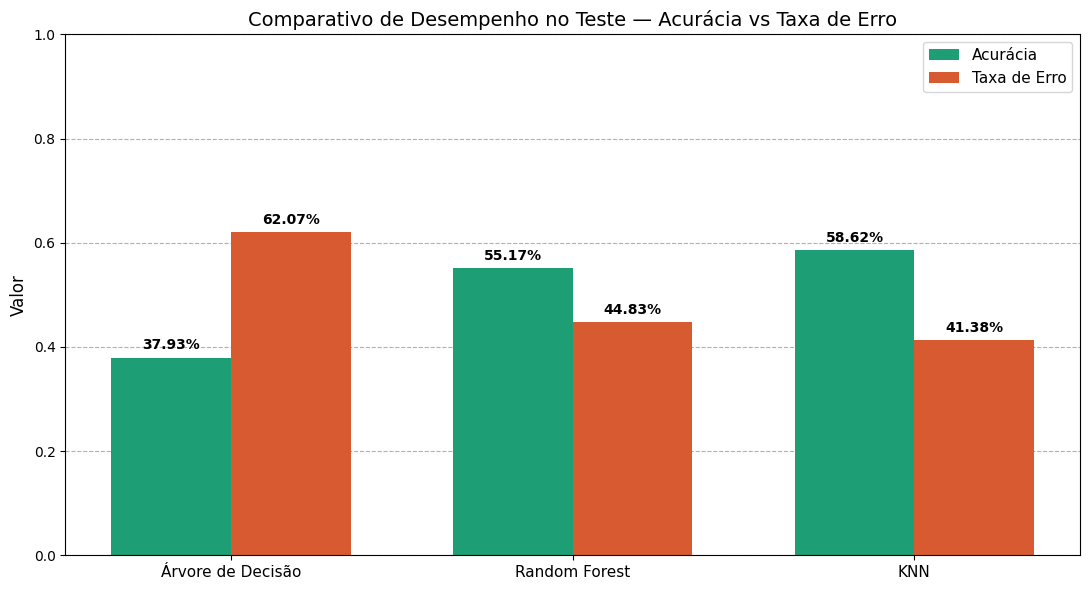

In [25]:
# Acurácias e Taxas de Erro
modelos = ['Árvore de Decisão', 'Random Forest', 'KNN']

acuracias_teste = [acuracia_test, acuracia_rf_test, acuracia_knn_test]
taxas_erro_teste = [taxa_erro_test, taxa_erro_rf_test, taxa_erro_knn_test]

x = np.arange(len(modelos))
largura = 0.35

fig, ax = plt.subplots(figsize=(11, 6))

barras_acc = ax.bar(x - largura/2, acuracias_teste, largura,
                    label='Acurácia', color='#1D9E75')
barras_err = ax.bar(x + largura/2, taxas_erro_teste, largura,
                    label='Taxa de Erro', color='#D85A30')

# Percentual
for barras in [barras_acc, barras_err]:
    for bar in barras:
        altura = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, altura + 0.01,
                f'{altura:.2%}', ha='center', va='bottom',
                fontsize=10, fontweight='bold')

ax.set_title('Comparativo de Desempenho no Teste — Acurácia vs Taxa de Erro',
             fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(modelos, fontsize=11)
ax.set_ylabel('Valor', fontsize=12)
ax.set_ylim(0, 1.0)
ax.yaxis.grid(True, linestyle='--')
ax.set_axisbelow(True)
ax.legend(fontsize=11)

plt.tight_layout()
plt.savefig('comparativo_acuracia_erro.png', dpi=300, bbox_inches='tight')
plt.show()

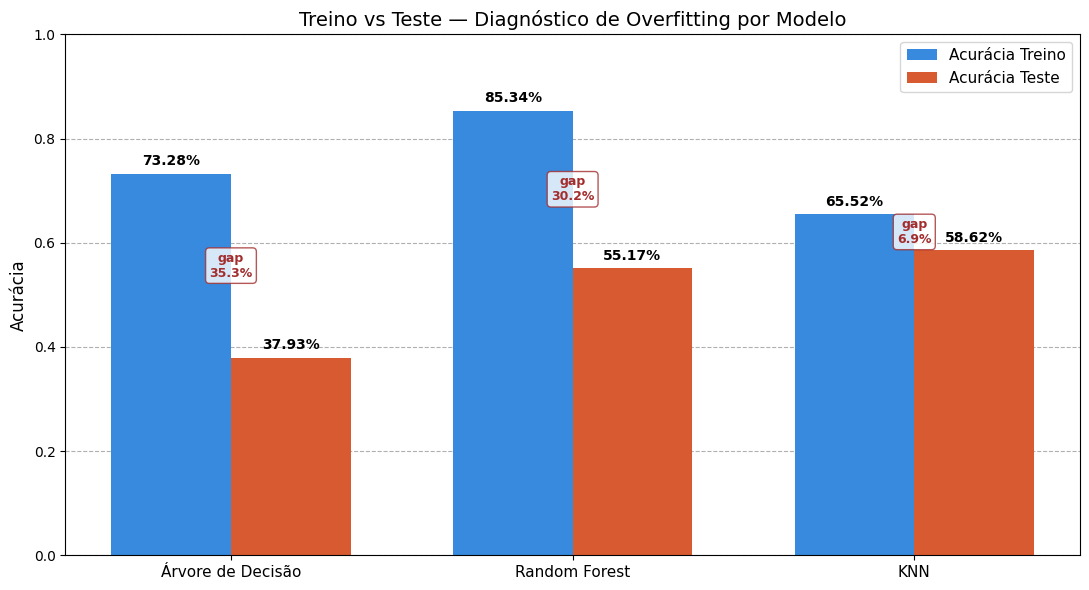

In [26]:
# Training Set e Test Set de cada modelo

acuracias_treino = [acuracia_train, acuracia_rf_train, acuracia_knn_train]
acuracias_teste  = [acuracia_test,  acuracia_rf_test,  acuracia_knn_test]

x = np.arange(len(modelos))
largura = 0.35

fig, ax = plt.subplots(figsize=(11, 6))

barras_treino = ax.bar(x - largura/2, acuracias_treino, largura,
                       label='Acurácia Treino', color='#378ADD')
barras_teste  = ax.bar(x + largura/2, acuracias_teste, largura,
                       label='Acurácia Teste', color='#D85A30')

for barras in [barras_treino, barras_teste]:
    for bar in barras:
        altura = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, altura + 0.01,
                f'{altura:.2%}', ha='center', va='bottom',
                fontsize=10, fontweight='bold')

for i in range(len(modelos)):
    gap = acuracias_treino[i] - acuracias_teste[i]
    y_meio = (acuracias_treino[i] + acuracias_teste[i]) / 2
    ax.text(i, y_meio, f'gap\n{gap:.1%}', ha='center', va='center',
            fontsize=9, color='#A32D2D', fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                      edgecolor='#A32D2D', alpha=0.8))

ax.set_title('Treino vs Teste — Diagnóstico de Overfitting por Modelo',
             fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(modelos, fontsize=11)
ax.set_ylabel('Acurácia', fontsize=12)
ax.set_ylim(0, 1.0)
ax.yaxis.grid(True, linestyle='--')
ax.set_axisbelow(True)
ax.legend(fontsize=11)

plt.tight_layout()
plt.savefig('comparativo_overfitting.png', dpi=300, bbox_inches='tight')
plt.show()

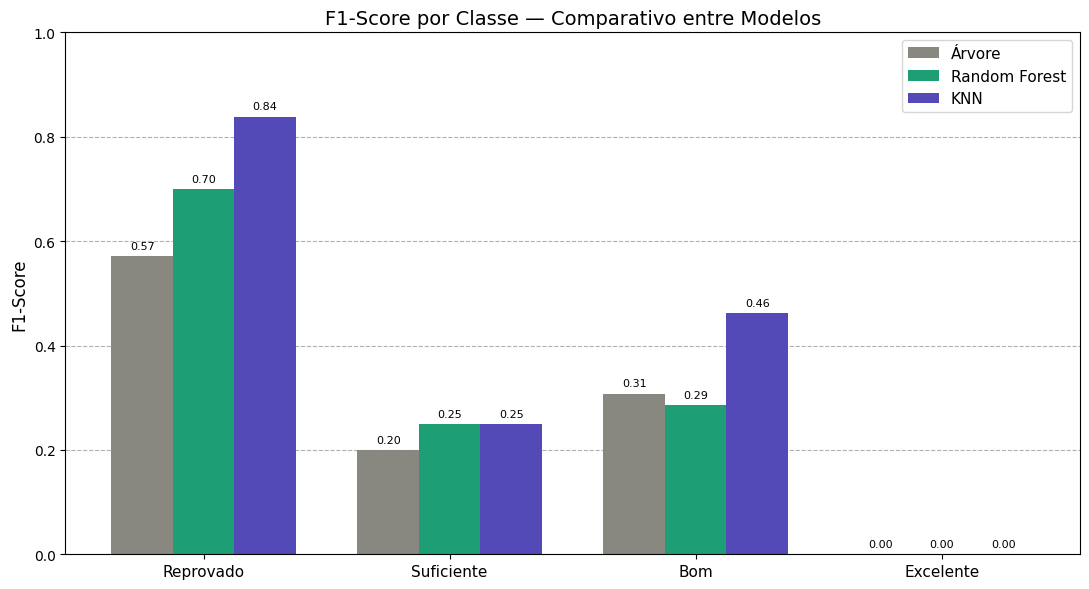

In [27]:
# F1-Score de cada classe nos 3 modelos

classes_ordem = ['Reprovado', 'Suficiente', 'Bom', 'Excelente']

# Calcula F1 por classe para cada modelo (average=None retorna um F1 por classe)
f1_tree = f1_score(y_test, y_pred_test, labels=classes_ordem, average=None)
f1_rf   = f1_score(y_test, y_pred_rf_test, labels=classes_ordem, average=None)
f1_knn  = f1_score(y_test, y_pred_knn_test, labels=classes_ordem, average=None)

x = np.arange(len(classes_ordem))
largura = 0.25

fig, ax = plt.subplots(figsize=(11, 6))

barras_t = ax.bar(x - largura, f1_tree, largura, label='Árvore', color='#888780')
barras_r = ax.bar(x,           f1_rf,   largura, label='Random Forest', color='#1D9E75')
barras_k = ax.bar(x + largura, f1_knn,  largura, label='KNN', color='#534AB7')

for barras in [barras_t, barras_r, barras_k]:
    for bar in barras:
        altura = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, altura + 0.01,
                f'{altura:.2f}', ha='center', va='bottom', fontsize=8)

ax.set_title('F1-Score por Classe — Comparativo entre Modelos', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(classes_ordem, fontsize=11)
ax.set_ylabel('F1-Score', fontsize=12)
ax.set_ylim(0, 1.0)
ax.yaxis.grid(True, linestyle='--')
ax.set_axisbelow(True)
ax.legend(fontsize=11)

plt.tight_layout()
plt.savefig('comparativo_f1_classe.png', dpi=300, bbox_inches='tight')
plt.show()